In [168]:
#Importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [169]:
#Loding datasets
df1 = pd.read_csv('train.csv')
df_train = pd.read_csv('train.csv')
df2 = pd.read_csv('test.csv')

In [170]:
df1.shape, df2.shape

((8693, 14), (4277, 13))

In [171]:
# #Trying pairplot to see the relationships between features [Bivariate Analysis]
# import seaborn as sns
# import matplotlib.pyplot as plt
# #Colored with target variable 'Transported'
# sns.pairplot(df1, hue='Transported')
# plt.show()

In [172]:
#Testing for null values
df1.isnull().sum().sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

In [173]:
#Testing for null values
df2.isnull().sum().sort_values(ascending=False)

FoodCourt       106
Spa             101
Cabin           100
ShoppingMall     98
Name             94
CryoSleep        93
VIP              93
Destination      92
Age              91
HomePlanet       87
RoomService      82
VRDeck           80
PassengerId       0
dtype: int64

In [174]:
#Let's merge both datasets and drop Transported column from training data
df1.drop('Transported', axis=1, inplace=True)
df = pd.concat([df1, df2], axis=0).reset_index(drop=True)
df.shape

(12970, 13)

In [175]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines


In [176]:
#Let's split PassengerId on two parts: group_id and group_size
df['group_id'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
df['group_size'] = df['PassengerId'].apply(lambda x: x.split('_')[1])

In [177]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,group_id,group_size
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0001,01
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,0002,01
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0003,01
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0003,02
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,0004,01


In [178]:
#Onehot encoding categorical features
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [179]:
df.head()

,PassengerId,Cabin,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,group_id,group_size,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True
0,0001_01,B/0/P,39.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0001,01,True,False,False,False,True,False
1,0002_01,F/0/S,24.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,0002,01,False,False,False,False,True,False
2,0003_01,A/0/S,58.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0003,01,True,False,False,False,True,True
3,0003_02,A/0/S,33.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0003,02,True,False,False,False,True,False
4,0004_01,F/1/S,16.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,0004,01,False,False,False,False,True,False


In [180]:
# Split Cabin column - this automatically handles missing values
cabin_split = df['Cabin'].str.split('/', expand=True)
df['deck'] = cabin_split[0]
df['num'] = cabin_split[1]
df['side'] = cabin_split[2]

In [181]:
df['num'] = pd.to_numeric(df['num'], errors='coerce')

In [182]:
df.sample(6)

,PassengerId,Cabin,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,group_id,group_size,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True,deck,num,side
10003,2808_02,C/95/P,44.0,0.0,9662.0,0.0,1.0,1260.0,Alsafik Platch,2808,02,True,False,False,False,True,False,C,95.0,P
12472,8269_01,NaN,25.0,4.0,0.0,1260.0,0.0,0.0,Gretty Smalls,8269,01,False,False,False,False,True,False,NaN,NaN,NaN
9924,2611_01,G/417/S,25.0,5.0,524.0,267.0,0.0,982.0,Fanne Kochroeders,2611,01,False,False,False,False,True,False,G,417.0,S
1143,1211_03,G/186/S,6.0,0.0,0.0,0.0,0.0,0.0,Bethy Pollarkeeks,1211,03,False,False,True,False,True,False,G,186.0,S
9620,1919_01,G/302/S,12.0,0.0,0.0,0.0,0.0,0.0,Samie Corman,1919,01,False,False,False,False,True,False,G,302.0,S
7282,7787_01,B/301/S,39.0,258.0,1541.0,0.0,NaN,621.0,Polari Cousel,7787,01,True,False,False,False,False,False,B,301.0,S


In [183]:
#Drop Cabin
df.drop('Cabin', axis=1, inplace=True)

In [184]:
#Finding the null values count after feature engineering
df.isnull().sum().sort_values(ascending=False)

ShoppingMall                 306
side                         299
num                          299
deck                         299
Name                         294
FoodCourt                    289
Spa                          284
Age                          270
VRDeck                       268
RoomService                  263
Destination_PSO J318.5-22      0
VIP_True                       0
Destination_TRAPPIST-1e        0
PassengerId                    0
CryoSleep_True                 0
HomePlanet_Mars                0
HomePlanet_Europa              0
group_id                       0
group_size                     0
dtype: int64

In [185]:
#Value counts of side, num and deck
print(df['side'].value_counts())
print(df['num'].value_counts())
print(df['deck'].value_counts())

side
S    6381
P    6290
Name: count, dtype: int64
num
82.0      34
4.0       28
56.0      28
95.0      27
31.0      27
          ..
1848.0     1
1847.0     1
1846.0     1
1844.0     1
1890.0     1
Name: count, Length: 1894, dtype: int64
deck
F    4239
G    3781
E    1323
B    1141
C    1102
D     720
A     354
T      11
Name: count, dtype: int64


In [186]:
#Let's create different deck name `U` for unknown/missing deck names
df['deck'].fillna('U', inplace=True)
df['side'].fillna('U', inplace=True)

/var/folders/4j/n0rl6b3s0657t_7z21qxxz6w0000gn/T/ipykernel_33608/1295094487.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['deck'].fillna('U', inplace=True)
/var/folders/4j/n0rl6b3s0657t_7z21qxxz6w0000gn/T/ipykernel_33608/1295094487.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [187]:
#One hot encode deck and side
df = pd.get_dummies(df, columns=['deck', 'side'], drop_first=True)
df.sample(6)

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,group_id,group_size,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True,num,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,deck_U,side_S,side_U
4866,5192_01,27.0,0.0,0.0,0.0,0.0,0.0,Tostex Khaf,5192,01,False,True,True,False,True,False,995.0,False,False,False,False,True,False,False,False,True,False
2151,2306_02,NaN,0.0,0.0,0.0,0.0,0.0,Gomeron Colensid,2306,02,True,False,False,False,True,False,82.0,False,True,False,False,False,False,False,False,False,False
11630,6476_01,59.0,0.0,1.0,0.0,34.0,872.0,Mathy Buckeelez,6476,01,False,False,False,False,True,False,1048.0,False,False,False,False,False,True,False,False,False,False
4471,4754_01,30.0,25.0,245.0,198.0,2.0,321.0,Lorian Milton,4754,01,False,False,False,False,False,False,307.0,False,False,False,True,False,False,False,False,True,False
9191,1072_01,57.0,0.0,0.0,0.0,0.0,0.0,Lonnis Arneras,1072,01,False,False,True,True,False,False,160.0,False,False,False,False,False,True,False,False,False,False
7191,7683_01,28.0,0.0,817.0,58.0,0.0,25.0,Katen Avisnydes,7683,01,False,False,False,False,True,False,1467.0,False,False,False,False,True,False,False,False,True,False


In [188]:
#Finding the null values count after feature engineering
df.isnull().sum().sort_values(ascending=False)

ShoppingMall                 306
num                          299
Name                         294
FoodCourt                    289
Spa                          284
Age                          270
VRDeck                       268
RoomService                  263
deck_F                         0
deck_D                         0
deck_E                         0
PassengerId                    0
deck_G                         0
deck_T                         0
deck_U                         0
deck_C                         0
side_S                         0
Destination_PSO J318.5-22      0
deck_B                         0
VIP_True                       0
Destination_TRAPPIST-1e        0
CryoSleep_True                 0
HomePlanet_Mars                0
HomePlanet_Europa              0
group_size                     0
group_id                       0
side_U                         0
dtype: int64

In [189]:
#Filling such that: ShoppingMall is filled '0', FoodCourt is filled '0', VRDeck is filled '0', Spa is filled '0', RoomService is filled '0'
df['ShoppingMall'].fillna(0, inplace=True)
df['FoodCourt'].fillna(0, inplace=True)
df['VRDeck'].fillna(0, inplace=True)
df['Spa'].fillna(0, inplace=True)
df['RoomService'].fillna(0, inplace=True)
#Filling Age with median value
df['Age'].fillna(df['Age'].median(), inplace=True)

/var/folders/4j/n0rl6b3s0657t_7z21qxxz6w0000gn/T/ipykernel_33608/3513057072.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ShoppingMall'].fillna(0, inplace=True)
/var/folders/4j/n0rl6b3s0657t_7z21qxxz6w0000gn/T/ipykernel_33608/3513057072.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [190]:
#Finding the null values count after feature engineering
df.isnull().sum().sort_values(ascending=False)

num                          299
Name                         294
PassengerId                    0
Destination_TRAPPIST-1e        0
side_S                         0
deck_U                         0
deck_T                         0
deck_G                         0
deck_F                         0
deck_E                         0
deck_D                         0
deck_C                         0
deck_B                         0
VIP_True                       0
Destination_PSO J318.5-22      0
Age                            0
CryoSleep_True                 0
HomePlanet_Mars                0
HomePlanet_Europa              0
group_size                     0
group_id                       0
VRDeck                         0
Spa                            0
ShoppingMall                   0
FoodCourt                      0
RoomService                    0
side_U                         0
dtype: int64

In [191]:
from sklearn.impute import KNNImputer

# Get the deck and side columns
deck_side_cols = [col for col in df.columns if col.startswith('deck_') or col.startswith('side_')]

# Combine with 'num' for imputation
impute_cols = ['num'] + deck_side_cols

# Fit and transform
imputer = KNNImputer(n_neighbors=5)
df[impute_cols] = imputer.fit_transform(df[impute_cols])

# Check for remaining nulls
df['num'].isnull().sum()

np.int64(0)

In [192]:
#Finding the null values count after feature engineering
df.isnull().sum().sort_values(ascending=False)

Name                         294
PassengerId                    0
Destination_TRAPPIST-1e        0
side_S                         0
deck_U                         0
deck_T                         0
deck_G                         0
deck_F                         0
deck_E                         0
deck_D                         0
deck_C                         0
deck_B                         0
num                            0
VIP_True                       0
Destination_PSO J318.5-22      0
Age                            0
CryoSleep_True                 0
HomePlanet_Mars                0
HomePlanet_Europa              0
group_size                     0
group_id                       0
VRDeck                         0
Spa                            0
ShoppingMall                   0
FoodCourt                      0
RoomService                    0
side_U                         0
dtype: int64

In [193]:
#Dropping name 
df.drop('Name', axis=1, inplace=True)
df.sample(6)

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group_id,group_size,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True,num,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,deck_U,side_S,side_U
12880,9083_02,27.0,0.0,0.0,0.0,0.0,0.0,9083,02,False,True,True,False,True,False,581.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11752,6704_01,34.0,0.0,0.0,0.0,0.0,0.0,6704,01,False,True,False,False,True,False,442.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9460,1557_01,32.0,0.0,10711.0,0.0,189.0,20.0,1557,01,True,False,False,False,False,False,67.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7705,8222_01,43.0,1054.0,109.0,576.0,645.0,0.0,8222,01,False,True,False,False,True,False,257.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8048,8606_02,24.0,13.0,221.0,0.0,1154.0,0.0,8606,02,False,False,False,False,True,False,1658.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7073,7525_02,61.0,0.0,0.0,0.0,0.0,0.0,7525,02,True,False,True,False,False,False,279.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [194]:
df.shape

(12970, 26)

In [195]:
#Finding data types
df.dtypes

PassengerId                   object
Age                          float64
RoomService                  float64
FoodCourt                    float64
ShoppingMall                 float64
Spa                          float64
VRDeck                       float64
group_id                      object
group_size                    object
HomePlanet_Europa               bool
HomePlanet_Mars                 bool
CryoSleep_True                  bool
Destination_PSO J318.5-22       bool
Destination_TRAPPIST-1e         bool
VIP_True                        bool
num                          float64
deck_B                       float64
deck_C                       float64
deck_D                       float64
deck_E                       float64
deck_F                       float64
deck_G                       float64
deck_T                       float64
deck_U                       float64
side_S                       float64
side_U                       float64
dtype: object

In [196]:
#Converting group_size and group_id to numeric
df['group_size'] = pd.to_numeric(df['group_size'], errors='coerce')
df['group_id'] = pd.to_numeric(df['group_id'], errors='coerce')
#Converting float columns to int
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('int64')

In [197]:
#Finding data types
df.dtypes

PassengerId                  object
Age                           int64
RoomService                   int64
FoodCourt                     int64
ShoppingMall                  int64
Spa                           int64
VRDeck                        int64
group_id                      int64
group_size                    int64
HomePlanet_Europa              bool
HomePlanet_Mars                bool
CryoSleep_True                 bool
Destination_PSO J318.5-22      bool
Destination_TRAPPIST-1e        bool
VIP_True                       bool
num                           int64
deck_B                        int64
deck_C                        int64
deck_D                        int64
deck_E                        int64
deck_F                        int64
deck_G                        int64
deck_T                        int64
deck_U                        int64
side_S                        int64
side_U                        int64
dtype: object

In [200]:
#Splitting back into train and test sets
df_train_final = df.iloc[:len(df_train), :].copy()
df_test_final = df.iloc[len(df_train):, :].copy()
#Adding Transported to df_train_final from original df_train and merging that on the basis of PassengerId
df_train_final = df_train_final.merge(df_train[['PassengerId', 'Transported']], on='PassengerId', how='left')

In [201]:
df_train_final.shape, df_test_final.shape

((8693, 27), (4277, 26))

In [202]:
#Unique group_id count
df['group_id'].nunique()

9280

In [203]:
#Train test split
X = df_train_final.drop(['PassengerId', 'Transported'], axis=1)
y = df_train_final['Transported']
#split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [204]:
X_train

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group_id,group_size,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True,num,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,deck_U,side_S,side_U
2333,28,0,55,0,656,0,2513,1,False,False,False,False,True,False,22,0,0,0,0,0,0,0,1,0,1
2589,17,0,1195,31,0,0,2774,2,False,False,False,False,True,False,575,0,0,0,0,1,0,0,0,0,0
8302,28,0,0,0,0,0,8862,4,True,False,True,False,False,False,329,0,1,0,0,0,0,0,0,1,0
8177,20,0,2,289,976,0,8736,2,False,True,False,False,True,False,1800,0,0,0,0,1,0,0,0,0,0
500,36,0,0,0,0,0,539,2,True,False,True,False,False,False,18,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,18,14,2,144,610,0,6076,1,False,False,False,False,True,False,988,0,0,0,0,0,1,0,0,1,0
5191,50,690,0,30,762,428,5537,1,False,True,False,False,True,False,1063,0,0,0,0,1,0,0,0,1,0
5390,22,158,0,476,0,26,5756,6,False,False,False,True,False,False,1194,0,0,0,0,1,0,0,0,0,0
860,34,379,0,1626,0,0,925,1,False,True,False,False,True,False,191,0,0,0,0,1,0,0,0,0,0


# Prediction

In [205]:
#Using XgBoost Classifier for prediction
model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)
#Predicting on validation set
y_pred = model.predict(X_val)
#Calculating accuracy
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_val, y_pred)
confusion = confusion_matrix(y_val, y_pred)
accuracy, confusion

/Users/ankitpokhrel/Desktop/kaggle_comp/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [01:16:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


(0.7958596894767107,
 array([[681, 180],
        [175, 703]]))

In [208]:
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Perceptron
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.svm import NuSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier  # Baseline model
from sklearn.semi_supervised import LabelPropagation
from sklearn.semi_supervised import LabelSpreading
from xgboost import XGBRFClassifier  # Random Forest variant
from catboost import CatBoostClassifier

In [211]:
#Using logistic regression, decision tree, random forest, xgboost, catboost, svc to predict the target variable 'Transported'
models = {
    'LGBMClassifier': LGBMClassifier(random_state=42, verbose=-1),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=2000),
    'RidgeClassifier': RidgeClassifier(random_state=42),
    'SGDClassifier': SGDClassifier(random_state=42),
    'Perceptron': Perceptron(random_state=42),
    'PassiveAggressiveClassifier': PassiveAggressiveClassifier(random_state=42),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'ExtraTreesClassifier': ExtraTreesClassifier(random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(random_state=42),
    'AdaBoostClassifier': AdaBoostClassifier(random_state=42),
    'BaggingClassifier': BaggingClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'ComplementNB': ComplementNB(),
    'SVC': SVC(random_state=42),
    'LinearSVC': LinearSVC(random_state=42, max_iter=2000),
    'NuSVC': NuSVC(random_state=42),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'NearestCentroid': NearestCentroid(),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=2000),
    'DummyClassifier': DummyClassifier(random_state=42),
    'LabelPropagation': LabelPropagation(),
    'LabelSpreading': LabelSpreading(),
    'XGBRFClassifier': XGBRFClassifier(random_state=42, eval_metric='logloss'),
    'CatBoostClassifier': CatBoostClassifier(random_state=42, verbose=0)
}
model_accuracies = {}
#Let's perform training and validation but validataion on 10 different data splits
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    model_accuracies[model_name] = accuracy
model_accuracies

/Users/ankitpokhrel/Desktop/kaggle_comp/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/Users/ankitpokhrel/Desktop/kaggle_comp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/ank

{'LGBMClassifier': 0.8016101207590569,
 'LogisticRegression': 0.780333525014376,
 'RidgeClassifier': 0.7596319723979299,
 'SGDClassifier': 0.6555491661874641,
 'Perceptron': 0.7515813686026452,
 'PassiveAggressiveClassifier': 0.6446233467510063,
 'DecisionTreeClassifier': 0.7464059804485337,
 'RandomForestClassifier': 0.7952846463484762,
 'ExtraTreesClassifier': 0.7889591719378953,
 'GradientBoostingClassifier': 0.7998849913743531,
 'HistGradientBoostingClassifier': 0.8050603795284647,
 'AdaBoostClassifier': 0.7717078780908568,
 'BaggingClassifier': 0.7878090856814262,
 'GaussianNB': 0.7389304197814837,
 'MultinomialNB': 0.7487061529614721,
 'BernoulliNB': 0.7400805060379528,
 'ComplementNB': 0.7487061529614721,
 'SVC': 0.772857964347326,
 'LinearSVC': 0.78205865439908,
 'NuSVC': 0.7751581368602645,
 'KNeighborsClassifier': 0.7492811960897068,
 'NearestCentroid': 0.6745255894192065,
 'LinearDiscriminantAnalysis': 0.7596319723979299,
 'MLPClassifier': 0.7561817136285222,
 'DummyClassifi

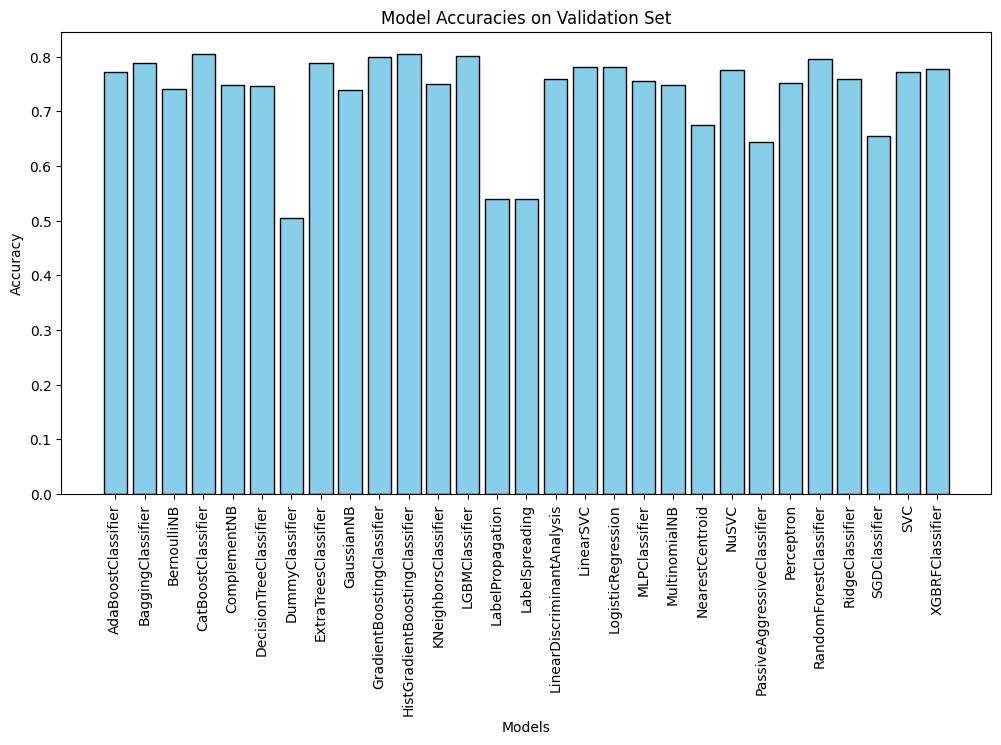

In [218]:
#Plotting model accuracies in bar graph in sorted order in ascending order
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(sorted(model_accuracies.keys()), [model_accuracies[k] for k in sorted(model_accuracies.keys())], color='skyblue', edgecolor='black') #Sorted bar graph
plt.xticks(rotation=90)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracies on Validation Set')
plt.show()

In [ ]:
#Using logistic regression, decision tree, random forest, xgboost, catboost, svc to predict the target variable 'Transported'
models = {
    'LGBMClassifier': LGBMClassifier(random_state=42, verbose=-1),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=2000),
    'RidgeClassifier': RidgeClassifier(random_state=42),
    'SGDClassifier': SGDClassifier(random_state=42),
    'Perceptron': Perceptron(random_state=42),
    'PassiveAggressiveClassifier': PassiveAggressiveClassifier(random_state=42),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'ExtraTreesClassifier': ExtraTreesClassifier(random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(random_state=42),
    'AdaBoostClassifier': AdaBoostClassifier(random_state=42),
    'BaggingClassifier': BaggingClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'ComplementNB': ComplementNB(),
    'SVC': SVC(random_state=42),
    'LinearSVC': LinearSVC(random_state=42, max_iter=2000),
    'NuSVC': NuSVC(random_state=42),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'NearestCentroid': NearestCentroid(),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=2000),
    'DummyClassifier': DummyClassifier(random_state=42),
    'LabelPropagation': LabelPropagation(),
    'LabelSpreading': LabelSpreading(),
    'XGBRFClassifier': XGBRFClassifier(random_state=42, eval_metric='logloss'),
    'CatBoostClassifier': CatBoostClassifier(random_state=42, verbose=0)
}
model_accuracies = {}
#Let's perform training and validation but validataion on 10 different data splits
for model_name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    model_accuracies[model_name] = accuracy
model_accuracies

/Users/ankitpokhrel/Desktop/kaggle_comp/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/Users/ankitpokhrel/Desktop/kaggle_comp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'LGBMClassifier': 0.8878665899942496,
 'LogisticRegression': 0.7826336975273146,
 'RidgeClassifier': 0.765382403680276,
 'SGDClassifier': 0.6589994249568718,
 'Perceptron': 0.6935020126509488,
 'PassiveAggressiveClassifier': 0.6538240368027602,
 'DecisionTreeClassifier': 1.0,
 'RandomForestClassifier': 1.0,
 'ExtraTreesClassifier': 1.0,
 'GradientBoostingClassifier': 0.8131109833237493,
 'HistGradientBoostingClassifier': 0.882691201840138,
 'AdaBoostClassifier': 0.7780333525014376,
 'BaggingClassifier': 0.9879240943070731,
 'GaussianNB': 0.7423806785508913,
 'MultinomialNB': 0.7452558941920644,
 'BernoulliNB': 0.7400805060379528,
 'ComplementNB': 0.7452558941920644,
 'SVC': 0.7757331799884991,
 'LinearSVC': 0.7797584818861415,
 'NuSVC': 0.7780333525014376,
 'KNeighborsClassifier': 0.8113858539390454,
 'NearestCentroid': 0.6710753306497987,
 'LinearDiscriminantAnalysis': 0.765382403680276,
 'QuadraticDiscriminantAnalysis': 0.7481311098332375,
 'MLPClassifier': 0.7763082231167338,
 'Dum

In [ ]:
#Let's use XGBoost for final prediction on test set
final_model = XGBClassifier(random_state=42, eval_metric='logloss')
final_model.fit(X, y)
#Predicting on test set
test_predictions = final_model.predict(df_test_final.drop('PassengerId', axis=1))

In [156]:
#Making submission file; The Transported column should be boolean
submission = pd.DataFrame({
    'PassengerId': df_test_final['PassengerId'],
    'Transported': test_predictions.astype(bool)
})
submission.to_csv('submission.csv', index=False)

In [163]:
#Let's use LGBMClassifier
final_model = LGBMClassifier(random_state=42, verbose=-1)
final_model.fit(X, y)
#Predicting on test set
test_predictions = final_model.predict(df_test_final.drop('PassengerId', axis=1))
#Making submission file; The Transported column should be boolean
submission = pd.DataFrame({
    'PassengerId': df_test_final['PassengerId'],
    'Transported': test_predictions.astype(bool)
})
submission.to_csv('submission_lgbm.csv', index=False)

In [ ]:
#Let's use 'CatBoostClassifier': CatBoostClassifier(random_state=42, verbose=0)
final_model = CatBoostClassifier(random_state=42, verbose=0)
final_model.fit(X, y)
#Predicting on test set
test_predictions = final_model.predict(df_test_final.drop('PassengerId', axis=1))
#Making submission file; The Transported column should be boolean
submission = pd.DataFrame({
    'PassengerId': df_test_final['PassengerId'],
    'Transported': test_predictions.astype(bool)
})
submission.to_csv('submission_catboost.csv', index=False)

In [165]:
#Let's use 'CatBoostClassifier': CatBoostClassifier(random_state=42, verbose=0)
final_model = BaggingClassifier(random_state=42)
final_model.fit(X, y)
#Predicting on test set
test_predictions = final_model.predict(df_test_final.drop('PassengerId', axis=1))
#Making submission file; The Transported column should be boolean
submission = pd.DataFrame({
    'PassengerId': df_test_final['PassengerId'],
    'Transported': test_predictions.astype(bool)
})
submission.to_csv('submission_bagging.csv', index=False)

In [158]:
#Using random forest for feature importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feature_importances

group_id                     0.113900
num                          0.113745
Age                          0.100585
Spa                          0.099756
CryoSleep_True               0.094316
VRDeck                       0.089759
RoomService                  0.083440
FoodCourt                    0.075398
ShoppingMall                 0.066168
group_size                   0.027402
HomePlanet_Europa            0.021965
side_S                       0.021631
deck_G                       0.014531
HomePlanet_Mars              0.014245
Destination_TRAPPIST-1e      0.014137
deck_F                       0.014109
deck_E                       0.009336
Destination_PSO J318.5-22    0.006935
deck_C                       0.006653
deck_B                       0.006366
deck_D                       0.003442
VIP_True                     0.002103
deck_T                       0.000076
dtype: float64